<a href="https://colab.research.google.com/github/ffahrialfikri/Data-Science-2026/blob/main/pertemuan13_fikrialfahri_250401020144.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama: Fikri Alfahri
Kelas: IF405
NIM: 250401020144

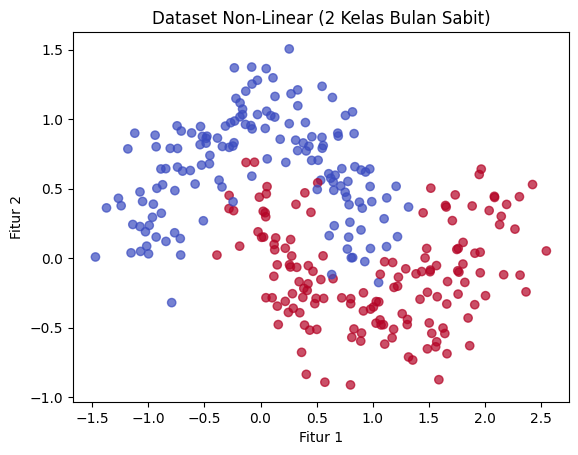

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.900


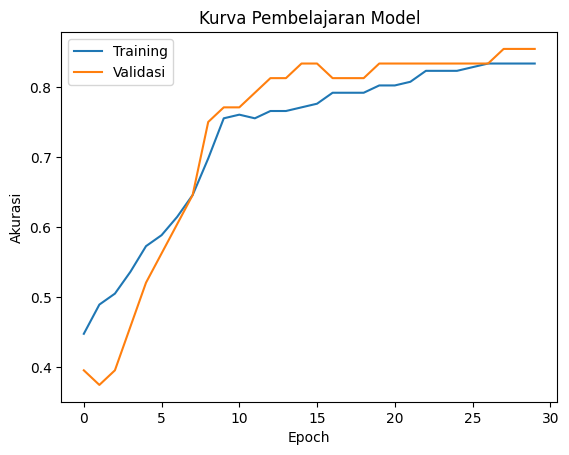

Jumlah kata unik: 120
Contoh 10 kata pertama: ['akan' 'aksesoris' 'amanah' 'asal' 'asalan' 'aturan' 'bagus' 'bahan'
 'baik' 'banget']
Akurasi model sentimen: 0.750
Kalimat: 'Pelayanan sangat memuaskan dan ramah'
Prediksi Sentimen: Positif


In [ ]:
# Langkah 0: Import Library Utama
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Langkah 1: Generate & Eksplorasi Dataset Non-Linear
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.show()

# Langkah 2: Bangun & Latih Neural Network Sederhana
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_tr, y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

# Langkah 3: Evaluasi & Visualisasi Kurva Belajar
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model')
plt.show()

# Langkah 4: Siapkan Dataset Ulasan Produk
ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Sangat menyukai produk ini, kemasan rapi',
    'Pengiriman lambat dan respon penjual cuek',
    'Pelayanan ramah dan barang ori',
    'Barang KW, menyesal beli di sini',
    'Kualitas mantap, fungsi bekerja baik',
    'Bahan tipis dan gampang rusak',
    'Respon cepat, penjual sangat amanah',
    'Aturan garansi tidak jelas, kecewa',
    'Produk bekerja dengan sangat sempurna',
    'Packing asal-asalan, kardus penyok',
    'Sangat bagus, sesuai gambar dan deskripsi',
    'Uang terbuang sia-sia, barang tidak menyala',
    'Pengiriman super cepat, mantap!',
    'Tidak recommended, pelayanan sangat buruk',
    'Harga murah tapi kualitas tidak murahan',
    'Barang cacat, tidak bisa dipakai',
    'Kualitas luar biasa, melebihi ekspektasi',
    'Sangat lambat, butuh dua minggu baru sampai',
    'Amanah sekali toko ini, pertahankan!',
    'Produk tidak lengkap, aksesoris hilang',
    'Sangat puas dengan pembelian kali ini',
    'Produk buruk, tombol tidak merespon',
    'Sangat bagus dan penjual komunikatif',
    'Barang tidak berfungsi sama sekali',
    'Material kokoh dan terasa premium',
    'Penjual penipu, barang tidak dikirim',
    'Desain keren dan fungsionalitas oke',
    'Pesan warna hitam dikirim warna putih',
    'Sangat puas, kualitas bintang lima',
    'Sangat mengecewakan, jahitan lepas',
    'Produk original dan masih tersegel',
    'Baterai boros dan cepat panas',
    'Top banget, tidak menyesal belanja di sini',
    'Sangat parah, tidak mau beli lagi'
]

label = [
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0
]

# Langkah 5: Ubah Teks Menjadi TF-IDF
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print('Contoh 10 kata pertama:', tfidf.get_feature_names_out()[:10])

# Langkah 6: Latih Model Klasifikasi Sentimen & Evaluasi
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42
)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print(f"Kalimat: '{kalimat_baru[0]}'")
print('Prediksi Sentimen:', 'Positif' if pred[0] == 1 else 'Negatif')

## Kesimpulan:

Kode ini terdiri dari beberapa langkah utama yang mendemonstrasikan implementasi dasar dari Neural Network untuk klasifikasi data non-linear dan klasifikasi sentimen teks menggunakan Logistic Regression dan TF-IDF.

*   **Langkah 0: Import Library Utama**
    Mengimpor semua library Python yang dibutuhkan seperti `matplotlib` untuk visualisasi, `sklearn` untuk dataset dan pre-processing, serta `tensorflow.keras` untuk membangun model neural network.

*   **Langkah 1: Generate & Eksplorasi Dataset Non-Linear**
    Membuat dataset sintetis berbentuk bulan sabit (`make_moons`) yang secara inheren non-linear, kemudian memvisualisasikannya untuk menunjukkan distribusi dua kelas.

*   **Langkah 2: Bangun & Latih Neural Network Sederhana**
    Membagi dataset non-linear menjadi data latih dan uji. Membangun model Neural Network Sequential dengan dua layer `Dense` (ReLU aktivasi) dan satu layer output (`sigmoid` aktivasi) untuk klasifikasi biner. Model dikompilasi dengan optimizer 'adam' dan 'binary_crossentropy' sebagai loss function, kemudian dilatih.

*   **Langkah 3: Evaluasi & Visualisasi Kurva Belajar**
    Mengevaluasi performa Neural Network pada data uji dan menampilkan akurasinya. Selain itu, memvisualisasikan kurva pembelajaran (akurasi training dan validasi) sepanjang epoch untuk melihat tren konvergensi model.

*   **Langkah 4: Siapkan Dataset Ulasan Produk**
    Menyiapkan dataset sederhana berupa daftar ulasan produk dalam bahasa Indonesia beserta label sentimen biner (1 untuk Positif, 0 untuk Negatif).

*   **Langkah 5: Ubah Teks Menjadi TF-IDF**
    Menggunakan `TfidfVectorizer` untuk mengubah teks ulasan produk menjadi representasi numerik (TF-IDF), yang merupakan bobot frekuensi kata dalam dokumen relatif terhadap korpus.

*   **Langkah 6: Latih Model Klasifikasi Sentimen & Evaluasi**
    Membagi dataset TF-IDF menjadi data latih dan uji. Melatih model `LogisticRegression` pada data latih untuk tugas klasifikasi sentimen, kemudian mengevaluasi akurasi model pada data uji. Terakhir, model digunakan untuk memprediksi sentimen dari sebuah kalimat baru.

## Library yang Digunakan:

Berikut adalah library Python yang digunakan dalam kode ini:

*   `matplotlib.pyplot`: Untuk membuat visualisasi data, seperti scatter plot dan kurva pembelajaran.
*   `sklearn.datasets`: Untuk menghasilkan dataset sintetis seperti `make_moons`.
*   `sklearn.model_selection`: Untuk membagi dataset menjadi subset training dan testing (`train_test_split`).
*   `tensorflow.keras.models.Sequential`: Untuk membangun model neural network secara sekuensial.
*   `tensorflow.keras.layers.Dense`: Untuk membuat layer terhubung penuh dalam neural network.
*   `sklearn.feature_extraction.text.TfidfVectorizer`: Untuk mengubah teks menjadi fitur TF-IDF.
*   `sklearn.linear_model.LogisticRegression`: Untuk melatih model klasifikasi sentimen.